# **Predict Ames Homes Prices ---- Advanced Regression Technique**

<a id="section_ID"></a> <br>
 # Table of Contents
 1. [Introduction](#1)
    1. [Business Objective](#7)
    2. [Problem Statement](#8)
2. [Exploratory Data Anlaysis](#2)
   1. [Data Ingestion & Understanding](#7)
   2. [Univariate & Multivariate Feature Analysis](#8)

# __Introduction__

The Ames Housing dataset, created by Dean De Cock for educational use in data science, contains detailed records of residential property sales in Ames, Iowa between 2006 and 2010. It includes 2,919 observations and a rich set of explanatory variables: 23 nominal, 23 ordinal, 14 discrete, and 20 continuous features, all designed to capture the many factors that influence home values.

# Business Objective

In today's dynamic real estate market, accurate house price prediction is crucial for various stakeholders:
 - **Home Buyers** : Want to ensure making fair offers.
 - **Sellers** : Need to set compeitive listing prices.
 - **Real Estate Agents** : Need reliable price estimates to advise clinets effectively.
 - **Investors** : Require accurate valuation for investment decisions.

# Problem Statement
This project implements a machine learning solution to analyze various house dimensions to predict sale prices, helping stakeholders to make data-driven decisions.

# Import Libraries

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sidetable
import sklearn
import feature_engine
import scipy
import dvc 
import kaggle
import os
import zipfile
from pathlib import Path

%matplotlib inline
sns.set_style('darkgrid')


# Display Settings

In [96]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", '{:.2f}'.format)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Data Ingestion & Understanding

In [38]:
from pathlib import Path
import pandas as pd
files = []
path_data = Path.cwd().parent.joinpath("data", "raw")
for file in path_data.rglob("*.csv"):
    files.append(file)
    print(file.name)
    print(files.index(file), " ", file)

sample_submission.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\sample_submission.csv
test.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\test.csv
train.csv
2   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\train.csv


In [41]:
# Load data
df_train = pd.read_csv(files[2], index_col='Id')
df_test = pd.read_csv(files[1], index_col='Id')

# Seperate features and target variable
X_train = df_train.drop(['SalePrice'], axis=1)
y = df_train.SalePrice

# Concatenate train and test data
X = pd.concat([X_train, df_test], axis=0)


In [42]:
# Basic info of datasets
print(f"Training Dataset Shape : {X_train.shape}")
print(f"Testing Dataset Shape : {df_test.shape}")


Training Dataset Shape : (1460, 79)
Testing Dataset Shape : (1459, 79)


In [44]:
# remove whitespace from columns name, replace space to '_' for columns name for conveince

X_train.columns = X_train.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")
df_test.columns = df_test.columns.str.strip().str.replace(" ", "_").str.replace(".", "_")

In [52]:
# Segregate numerical and categorical features
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
print(f"Total Numerical Columns : {len(num_cols)}\n", num_cols)

Total Numerical Columns : 36
 ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [49]:
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()
print(f"Total Categorical Columns : {len(cat_cols)}\n", cat_cols)

Total Categorical Columns : 43
 ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## **2. Exploratory Data Analysis**

#### **2.1. Sale Price**

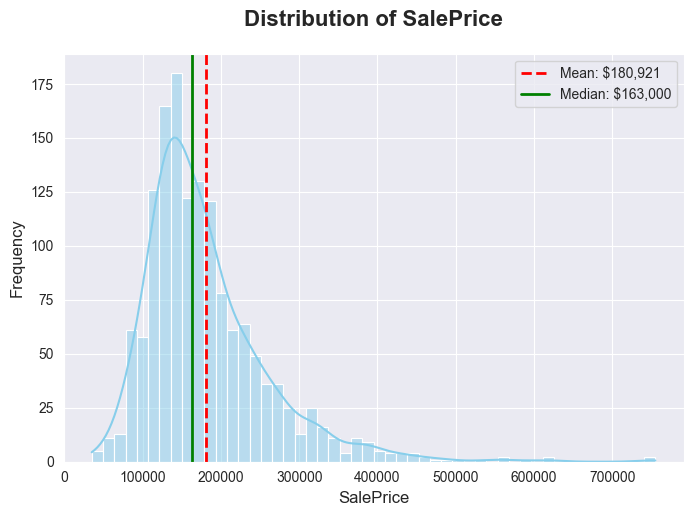

In [97]:
# Calculate statistics
mean_price = y.mean()
median_price = y.median()

# Plot histogram with KDE
fig = plt.figure(figsize=(8,6))
sns.histplot(y, kde=True, bins=50, color='skyblue')

# Add mean and median lines
plt.axvline(mean_price, color="red", linestyle="--", linewidth=2, label=f"Mean: ${mean_price:,.0f}")
plt.axvline(median_price, color="green", linestyle="-", linewidth=2, label=f"Median: ${median_price:,.0f}")

# Labels and legend
fig.subplots_adjust(bottom=0.2)
plt.title("Distribution of SalePrice", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("SalePrice", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.show()

In [71]:
print(f"""Skewness : {y.skew():.4f}
Kurtosis : {y.kurtosis():.4f}""")

Skewness : 1.8829
Kurtosis : 6.5363


The distribution of `SalePrice` is right-skewed.

#### **2.2. Numerical Features**

Top 10 numerical features highly correlated with SalePrice:


In [77]:
corr_matrix = df_train.select_dtypes(include=[np.number]).corr()['SalePrice'].sort_values(ascending=False)
top_10_corr = corr_matrix.head(11)
top_10_corr

SalePrice      1.00
OverallQual    0.79
GrLivArea      0.71
GarageCars     0.64
GarageArea     0.62
TotalBsmtSF    0.61
1stFlrSF       0.61
FullBath       0.56
TotRmsAbvGrd   0.53
YearBuilt      0.52
YearRemodAdd   0.51
Name: SalePrice, dtype: float64

__What are the top 10 features selected by Recursive Feature Elimination?__


In [106]:
from sklearn.feature_selection import RFE, f_regression, r_regression
from sklearn.linear_model import LinearRegression

model = LinearRegression()
rfe = RFE(estimator=model, n_features_to_select=10, step=1)
selector = rfe.fit(X_train.fillna(0).select_dtypes(exclude='object'), y)
selected_features = list(
    X_train.select_dtypes(exclude='object').columns[selector.support_]
)
selected_features

['OverallQual',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars']

Based on the analyses, features such as __Overall Quality, Living Area, Garage Size, Number of Full Baths, and Year Built__ emerge as key determinants of house prices. Let's explore these features in greater detail.

**Overall Quality**

Overall quality is the most important feature in both analyses. It is clear that higher quality makes the house more expensive.



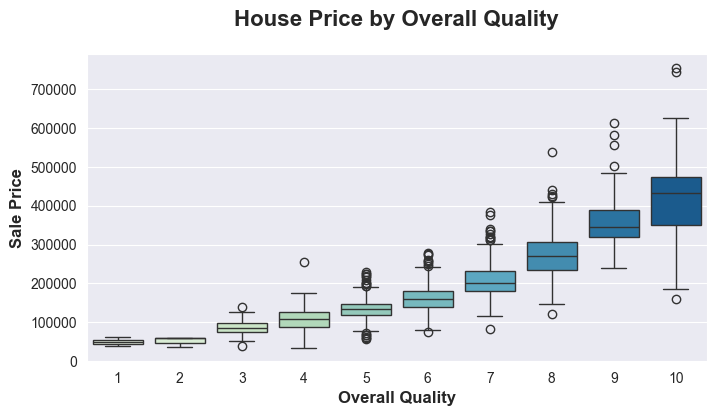

In [98]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(x='OverallQual', y='SalePrice', data=df_train, palette='GnBu')
ax.set_title('House Price by Overall Quality', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Overall Quality', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **Living Area**

The living area shows a clear linear relationship with house price. In the scatter plot, however, several __outliers__ are evident—most notably two properties in the lower-right corner with more than __4,000 square feet__ of living space but priced below __$200,000__.

Correlation : 0.7086244776126515


<Figure size 600x400 with 0 Axes>

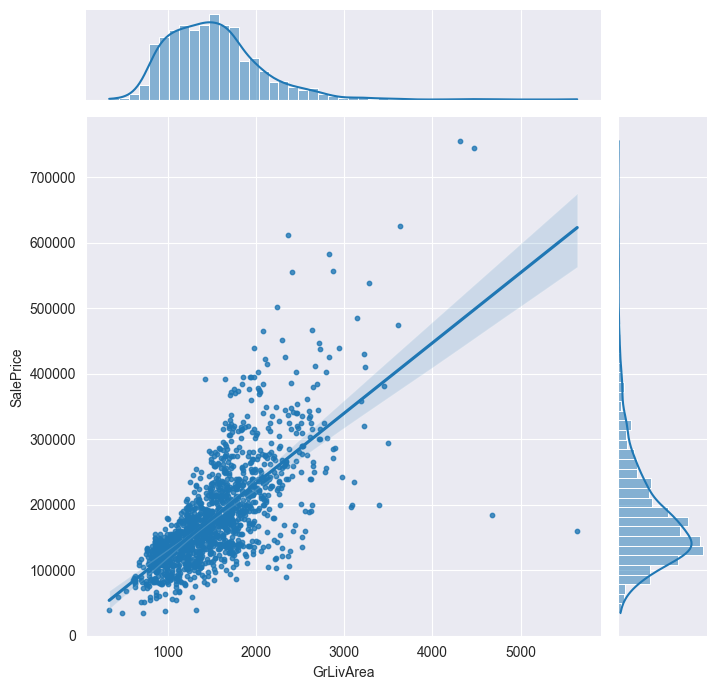

In [99]:
def plot_correlation(features):
    """
    1. Plot correlation of two features
    2. Create Joint plot of two features
    """
    # print correlation
    print("Correlation :", df_train[[features[0], features[1]]].corr().iloc[1, 0])

    # Create joint plot
    plt.figure(figsize=(6, 4))
    sns.jointplot(data = df_train, x= features[0], y=features[1], kind='reg', height=7, scatter_kws={'s': 10}, marginal_kws={'kde': True})
    

plot_correlation(['GrLivArea', 'SalePrice'])
plt.show()

#### **GarageCars**

It's surprising that houses with __four-car garages__ are actually priced lower than those with __three-car garages__.

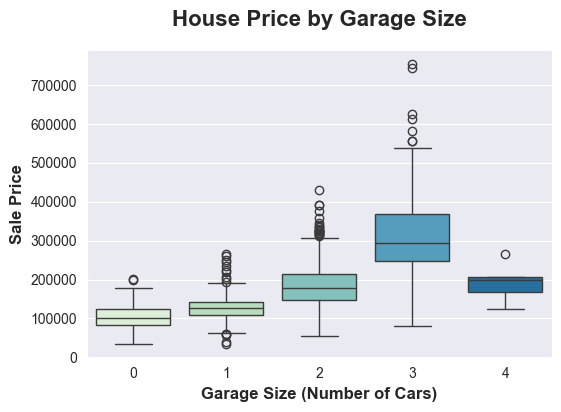

In [101]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x='GarageCars', y='SalePrice', data=df_train, palette='GnBu', ax=ax)
ax.set_title('House Price by Garage Size', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax.set_xlabel('Garage Size (Number of Cars)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **Year Built**

The age of a house is another key factor influencing its price. In general, newer homes command higher average values, though there are also several pre‑1900 properties that stand out with notably high prices.

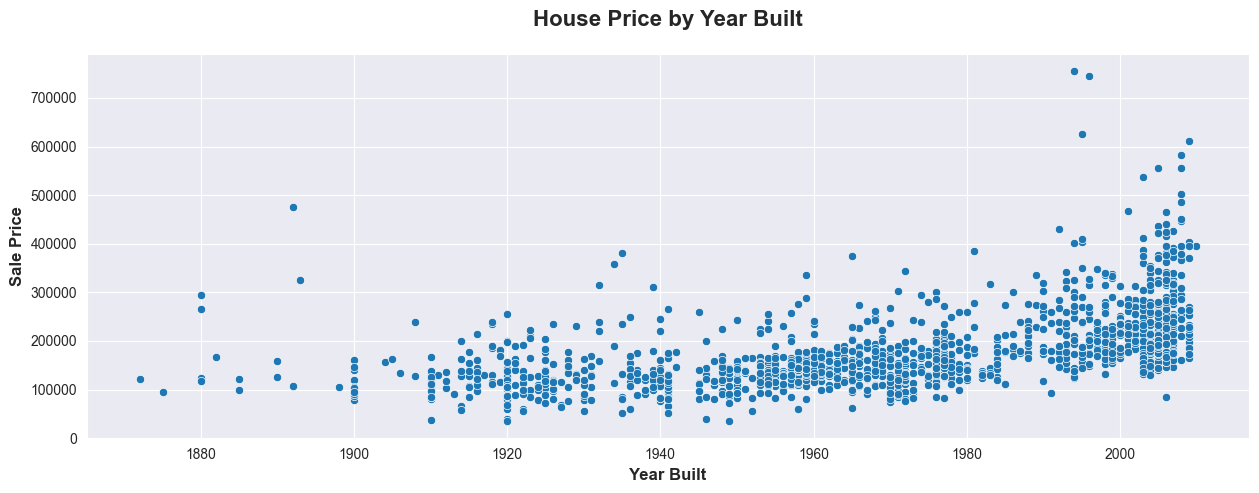

In [103]:
fig, ax = plt.subplots(figsize=(15, 5))
sns.scatterplot(x='YearBuilt', y='SalePrice', data=df_train, ax=ax)
ax.set_title('House Price by Year Built', fontdict={'fontsize': 16, 'fontweight': 'bold'}, y=1.05)
ax.set_xlabel('Year Built', fontsize=12, fontweight='bold')
ax.set_ylabel('Sale Price', fontsize=12, fontweight='bold')
plt.show()


#### **2.3. Categorical Variables**

In [152]:
from sklearn.preprocessing import LabelEncoder
from scipy import stats
# Select Categorical features
cat_columns = df_train.select_dtypes(include='object').columns
target_data = df_train['SalePrice']

# store results
results = []

for col in cat_columns:
    # Group the numerical data by the categorical column
    groups = [target_data[df_train[col] == category] for category in df_train[col].unique()]
    # Perform ANOVA test
    f_value, p_value = stats.f_oneway(*groups)
    # Append the results to the list
    results.append({
        'Feature': col,
        'F_value': f_value,
        'P_value': p_value
    })
# Create a DataFrame from the results
results_df = pd.DataFrame(results)
# Sort the DataFrame by F_value and P_value in descending order
results_df = results_df.sort_values(by=['F_value'], ascending=False).reset_index(drop=True)
# select top 15 features
top_features = results_df[results_df['P_value'] < 0.01].head(1)
print(top_features)

     Feature  F_value  P_value
0  ExterQual   443.33     0.00


In [151]:
import pandas as pd
from scipy.stats import f_oneway

# Load dataset
#train = pd.read_csv("train.csv")

# Target variable
y = df_train["SalePrice"]

# Identify categorical features
categorical_features = df_train.select_dtypes(include=["object"]).columns

anova_results = []

# Perform one-way ANOVA for each categorical feature
for col in categorical_features:
    groups = []
    for category in df_train[col].dropna().unique():
        groups.append(y[df_train[col] == category])
    
    # Run ANOVA only if there are at least 2 groups
    if len(groups) > 1:
        f_stat, p_val = f_oneway(*groups)
        anova_results.append((col, f_stat, p_val))

# Convert to DataFrame
anova_df = pd.DataFrame(anova_results, columns=["Feature", "F-Statistic", "p-value"])

# Filter features with p-value < 0.01
significant_features = anova_df[anova_df["p-value"] < 0.01]

# Sort by p-value and select top 15
top_15 = significant_features.sort_values("F-Statistic", ascending=False).reset_index(drop=True).head(1)

print(top_15)


     Feature  F-Statistic  p-value
0  ExterQual       443.33     0.00


In [148]:
set(top_15['Feature']).intersection(set(top_features['Feature']))

{'CentralAir',
 'ExterQual',
 'Foundation',
 'HeatingQC',
 'KitchenQual',
 'LotShape',
 'MSZoning',
 'Neighborhood',
 'PavedDrive',
 'SaleCondition'}

In [150]:
# Separate target and features
X = df_train.drop(columns=["SalePrice"])
y = df_train["SalePrice"]

# Encode categorical variables numerically
X_encoded = X.select_dtypes(include=["object"]).copy()
for col in X_encoded.columns:
    X_encoded[col] = LabelEncoder().fit_transform(X_encoded[col].astype(str))

# Handle missing values (fill with median for numeric, mode for categorical)
for col in X_encoded.columns:
    if X_encoded[col].dtype == "object":
        X_encoded[col].fillna(X_encoded[col].mode()[0], inplace=True)
    else:
        X_encoded[col].fillna(X_encoded[col].median(), inplace=True)

# Run ANOVA F-test (linear regression method)
f_stats, p_values = f_regression(X_encoded, y)

# Create DataFrame of results
anova_results = pd.DataFrame({
    "Feature": X_encoded.columns,
    "F-Statistic": f_stats,
    "p-value": p_values
})

# Sort by p-value and select top 15
top_var = anova_results#.sort_values("p-value")#.head(15)
top_var = top_var[top_var["p-value"] < 0.01].sort_values("F-Statistic", ascending=False).reset_index(drop=True).head(1)
print(top_var)

     Feature  F-Statistic  p-value
0  ExterQual       994.98     0.00


In [146]:
len(set(top_var['Feature']).intersection(set(top_15['Feature'])))

11

In [147]:
print(len(set(top_var['Feature']).intersection(set(top_15['Feature']))))
print(len(set(top_15['Feature']).intersection(set(top_features['Feature']))))
print(len(set(top_var['Feature']).intersection(set(top_features['Feature']))))

11
10
8


#### **2.4. Correlations**

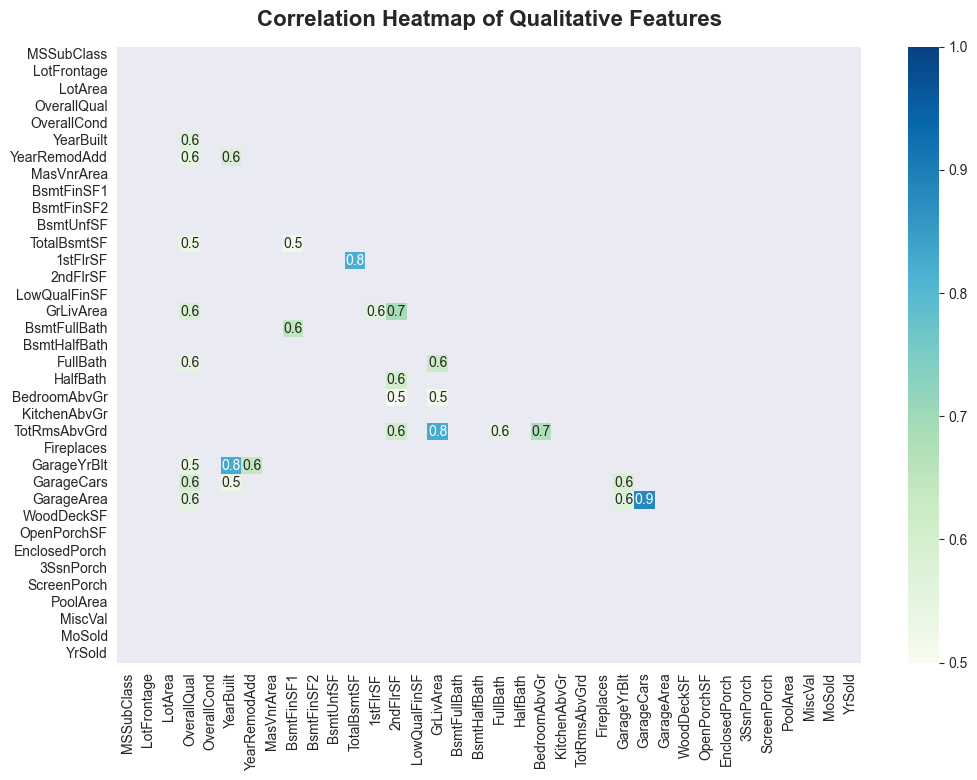

In [157]:
# Create correlation matrix from train data excluding `SalePrice`
corr_mat = df_train.iloc[:, :-1].select_dtypes(include=[np.number]).corr()

# Select correlations greater than 0.5
high_corr_mat = corr_mat[abs(corr_mat) >= 0.5]

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(high_corr_mat,mask = np.triu(np.ones_like(high_corr_mat, dtype=bool)),
            annot=True,
            fmt='.1f',
            cmap='GnBu',
            vmin=0.5,
            vmax=1)
plt.title('Correlation Heatmap of Qualitative Features', fontsize=16, fontweight='bold', y=1.02)
plt.grid(False)
plt.show()


Our training data shows evidence of multicollinearity, with several features exhibiting strong correlations with one another.
- GarageCars and GarageArea
- GarageYrBlt and YearBuilt
- 1stFlrSF and TotalBsmtSF
- GrLivArea and TotRmsAbvGrd

Multicollinearity negatively affects prediction models by increasing the standard errors of estimates. To address this, for each pair of highly correlated features,  will remove the one that shows a weaker correlation with `SalePrice`.

#### **2.5. Missing Values**

Most machine learning algorithms cannot be trained directly on datasets containing missing values. That’s why it’s crucial to detect them first and then decide whether to drop the affected features or impute the missing entries.

        Features  missing  total  percent columns_dtype
0         PoolQC     1453   1460    99.52        object
1    MiscFeature     1406   1460    96.30        object
2          Alley     1369   1460    93.77        object
3          Fence     1179   1460    80.75        object
4     MasVnrType      872   1460    59.73        object
5    FireplaceQu      690   1460    47.26        object
6    LotFrontage      259   1460    17.74       float64
7     GarageQual       81   1460     5.55        object
8     GarageType       81   1460     5.55        object
9   GarageFinish       81   1460     5.55        object
10    GarageCond       81   1460     5.55        object
11   GarageYrBlt       81   1460     5.55       float64
12  BsmtExposure       38   1460     2.60        object
13  BsmtFinType2       38   1460     2.60        object
14      BsmtQual       37   1460     2.53        object


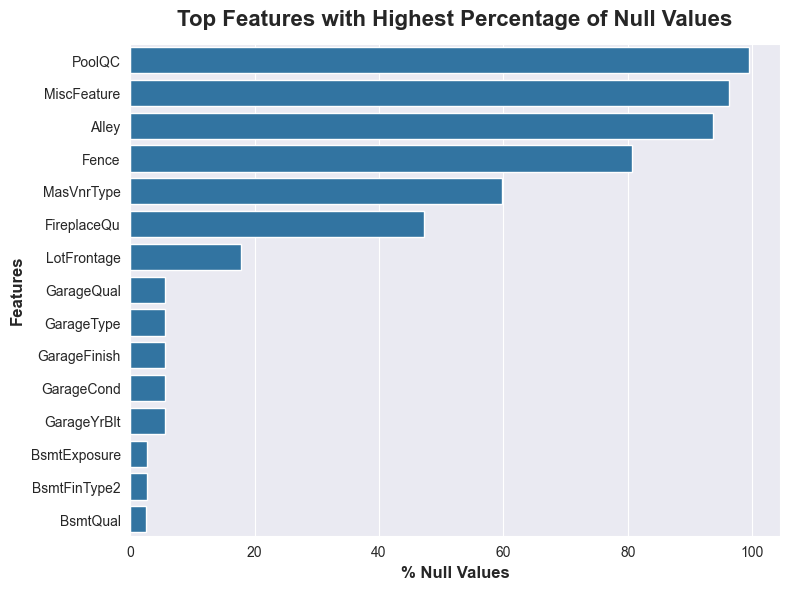

In [159]:
def plot_null_counts(df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame: 
    null_info = df.stb.missing().reset_index().rename({'index':'Features'},axis='columns').sort_values(by='percent',ascending=False)
    null_info['columns_dtype'] = [df[col].dtype for col in null_info['Features']]

    null_info = null_info.loc[null_info['missing']>0].head(top_n)
    print(null_info)

    plt.figure(figsize=(8,6))
    sns.barplot(x='percent', y='Features',data=null_info)
    plt.title('Top Features with Highest Percentage of Null Values', fontsize=16, fontweight='bold', y=1.02)
    plt.xlabel('% Null Values', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return


plot_null_counts(df_train)

zf = zipfile.ZipFile('E://house_price_prediction//Real-Estate-Price-Prediction//data//raw//house-prices-advanced-regression-techniques.zip') 
submission = pd.read_csv(zf.open('sample_submission.csv'))
test = pd.read_csv(zf.open('test.csv'))
train = pd.read_csv(zf.open('train.csv'))
description = pd.read_csv(zf.open('data_description.txt'),sep='\t',on_bad_lines='skip')

print(zf.namelist())

description

with zipfile.ZipFile('e:/house_price_prediction/Real-Estate-Price-Prediction/data/raw/zipped/house-prices-advanced-regression-techniques.zip','r') as zip_file:
    file_list = zip_file.namelist()
    print('The File List are :', file_list)

import logging
from zipfile import ZipFile
from pathlib import Path

#Extract all zipped files
def extract_all_file(input_path: Path, output_path: Path):
    with ZipFile(file= input_path) as f:
        f.extractall(path= output_path)

def main():
    #current file path 
    current_path = Path(__file__)
    #root directory path
    root_path = current_path.parent.parent.parent
    #raw data directory path
    raw_data_path = root_path / 'data' / 'raw'
    #output path for the zip files
    output_path = raw_data_path / 'extracted'
    #make the directory for the path
    output_path.mkdir(parents=True,exist_ok=True)
    #input path for zip files
    input_path = raw_data_path / 'zipped'

    


#Extract all files
extract_all_file(input_path = input_path,#/'house-prices-advanced-regression-techniques.zip',
                 output_path = output_path)

#call the main function
if __name__ == '__main__':
    main()

